# Построение ML системы для рекомендации мобильных тарифов

<a id='exintro'></a>
## Краткое описание

**Цель проекта** – определить, какой из двух тарифов («Смарт» или «Ультра») приносит больше выручки, и построить модель для рекомендации тарифа новым пользователям на основе их поведения. Требование к модели – точность не ниже 75%.

**Данные** – 500 клиентов (наблюдения за 2018 год): информация о звонках, сообщениях, интернет‑трафике и выбранном тарифе.

**Методология**:
- Изучение и предобработка данных.
- Разделение выборки на обучающую, валидационную и тестовую.
- Обучение трёх моделей: решающее дерево, случайный лес, логистическая регрессия.
- Оценка точности и качества с помощью матрицы ошибок, полноты и т.д.

**Результаты**:
- Лучшие модели: **решающее дерево глубины 4** (точность 79,0%) и **случайный лес из 6 деревьев** (точность 78,8%).
- Обе модели превысили целевой порог 75%.
- Модель решающего дерева немного точнее и значительно производительнее, однако **плохо распознаёт тариф «Ультра»** (полнота всего 46% против 52% у случайного леса).

**Рекомендация**:
- Для оперативной обработки огромных объёмов данных (федеральный оператор) предпочтительнее **решающее дерево** – оно быстрее и даёт чуть более высокую общую точность.
- Если критично не упускать прибыль от дорогого тарифа «Ультра», стоит использовать **случайный лес** (выигрыш в полноте ~6%).
- Для устранения дисбаланса классов (перекос в сторону «Смарт») рекомендуется **балансировка выборки** – это повысит качество предсказаний по обоим тарифам.

**Заключение**: Заказчик может выбрать между производительностью (решающее дерево) и большей чувствительностью к дорогому тарифу (случайный лес). Наша рекомендация – меодель случайного леса в данном случае, а также по возможности дообучить модель на сбалансированных данных.

## Содержание

- [Краткое описание](#exintro)
- [Вступление](#intro)
- [Общий обзор данных](#view)
- [Разбиение данные на выборки](#samples)        
- [Исследование моделей](#models)
- [Проверка моделей на тестовой выборке](#testing)
- [Проверка модели на адекватность](#model_eval)
- [Модель рекомендаций и общие выводы](#outro)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from pathlib import Path

<a id='intro'></a>
## Введение

**Цель работы:**

Построить на тренировачных данных о переходов пользователей Мегафона на различные тарифы модель дяля подбора тарифа для пользователя. Добиться значения точности модели не ниже 0,75.

Пользователи переходят с архивных тарифов на два возможных - смарт или ультра.

Предоставленные данные - сведения о пользователях, уже перешедших на один из этих тарифов. 

На основании их требуется построить простую ML-модель с точностью не менее 75% на тестовой выборке, с макисально большой точностью из разобранных вариантов.

В работе мы: 
1. изучим данные
2. разобъем их на обучающую, валидационную и тестовую выборку
3. обучим и исследуем модели решающего дерева, случайного леса и логистической регрессии
4. проверим их на тестовой выборке
5. проверим их на адекватность при помощи матрицы ошибок, соотношения классов и т.д.

В конце мы предоставим модель для рекомендации тарифа и укажем на ее недостатки.

## Изучение предоставленных данных

### Краткое описание данных

Продолжим рассмотрением базовых характеристик данных:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


,calls,minutes,messages,mb_used,is_ultra
2993,45.0,358.45,55.0,12715.68,0
1666,81.0,435.42,7.0,18305.77,0
1268,72.0,578.68,50.0,15857.17,0
3166,71.0,506.27,98.0,19864.42,0
640,47.0,340.18,86.0,13022.89,1


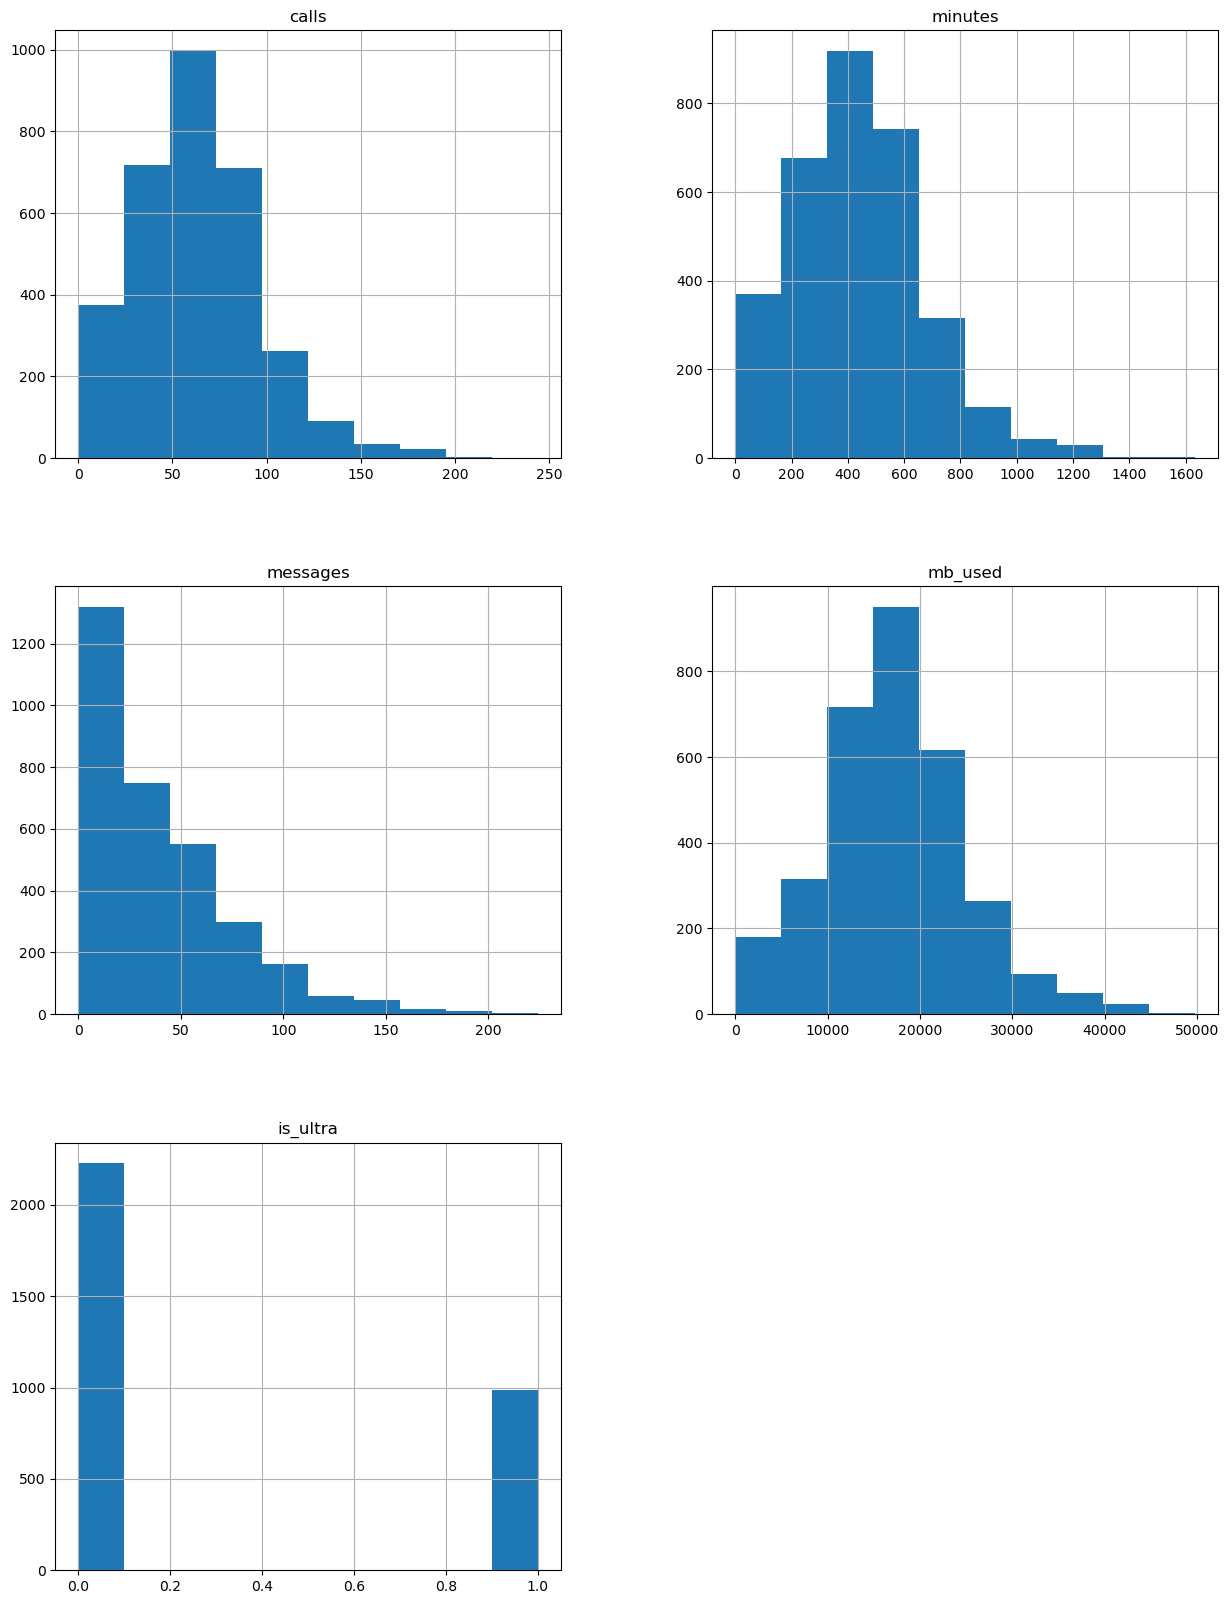

In [4]:
pd.set_option('display.max_columns', 50) 
# читаем файл
data_path = Path.cwd().parent / 'data' / 'users_behavior.csv'
raw_data = pd.read_csv(data_path, sep = ',')
# выводим обзорные данные о данных
raw_data.info()
display(raw_data.sample(5))
raw_data.hist(figsize=(15, 20))
None

Переименование столбцов не требуется, большинство на смарт-тарифе (а не на ультра), распределения похожи на обрезанные нормальные. Претензий в плане адекватности данных нет. 

### Легкие проверки и преобразование данных

На всякий случай проверим по принципу доверяй, но проверяй, пропуски в данных:

In [3]:
for column_name in raw_data.columns:
    print(f'Пропусков в {column_name}:', raw_data[column_name].isna().sum())
# print чтобы переносов не было

Пропусков в calls: 0
Пропусков в minutes: 0
Пропусков в messages: 0
Пропусков в mb_used: 0
Пропусков в is_ultra: 0


Возможно стоит перевести calls и messages в int? Если не потребуется совершать с ними операции деления, было бы разумно. Переведем, оставив необработанные данные в старых данных. Вдруг они понадобятся.

In [4]:
data = raw_data
data['calls'] = data['calls'].astype(int)
data['messages'] = data['messages'].astype(int)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   int64  
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   int64  
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 125.7 KB


Пропусков нет, можно начинать разботу с данными.

### Краткий итог

Осмотренные данные реалистичны, имеют скос в сторону тарфиа смарт, чуть-чуть изменены после осмотра - количество смс и количество звонков преведены в класс int64. Можно приступать к работе с ними.

<a id='samples'></a>
## Разбиение данные на выборки

### Разбиение данных на выборки и проверки данных

Разобьем данные на обучающую, тестовую и валидационную выборки в пропорции 60%, 20% и 20% соответственно:

In [5]:
# Чтобы не применять дважды train_test_split и портить случайное распределение, воспользуемся numpy.split:

train_data, validate_data, test_data = \
              np.split(data.sample(frac=1, random_state=12345), [int(.6*len(data)), int(.8*len(data))])

# Сначала мы случайным образом перемешиваем данные, а потом делим их последовательно.

Проверим, что данные разбились в правильной пропорции на всякий случай:

In [6]:
display('Размер тренировочной выборки составляет в процентах от исходной:', len(train_data)/len(data))
display('Размер валидационной выборки составляет в процентах от исходной:', len(validate_data)/len(data))
display('Размер тестовой выборки составляет в процентах от исходной:', len(test_data)/len(data))

'Размер тренировочной выборки составляет в процентах от исходной:'

0.5998755444928439

'Размер валидационной выборки составляет в процентах от исходной:'

0.2000622277535781

'Размер тестовой выборки составляет в процентах от исходной:'

0.2000622277535781

Отлично, все работает. Далее, для всех трех наборов данных, разделим данные на признаки и собственно целевой признак:

In [7]:
features_train = train_data.drop(['is_ultra'], axis=1)
target_train = train_data['is_ultra']
features_valid = validate_data.drop(['is_ultra'], axis=1)
target_valid = validate_data['is_ultra']
features_test = test_data.drop(['is_ultra'], axis=1)
target_test = test_data['is_ultra']

Проверим, что получилось то, что нужно:

In [8]:
display('Короткое описание тренировочных признаков:')
features_train.info()
display(features_train.head(10))
display('Описание тренировочного целевого признака:')
display(target_train)
display('Короткое описание тестовых признаков:')
features_test.info()
display(features_test.head(10))
display('Описание тестового целевого признака:')
display(target_test)

'Короткое описание тренировочных признаков:'

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1928 entries, 1415 to 848
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     1928 non-null   int64  
 1   minutes   1928 non-null   float64
 2   messages  1928 non-null   int64  
 3   mb_used   1928 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 75.3 KB


,calls,minutes,messages,mb_used
1415,82,507.89,88,17543.37
916,50,375.91,35,12388.40
1670,83,540.49,41,9127.74
686,79,562.99,19,25508.19
2951,78,531.29,20,9217.25
654,53,478.18,78,20152.53
2827,73,582.47,33,12095.91
1466,31,172.10,25,31077.59
2223,28,222.21,30,22986.30
2639,68,523.56,14,18910.66


'Описание тренировочного целевого признака:'

1415    1
916     0
1670    0
686     1
2951    0
       ..
2104    1
2442    1
1265    0
1635    0
848     0
Name: is_ultra, Length: 1928, dtype: int64

'Короткое описание тестовых признаков:'

<class 'pandas.core.frame.DataFrame'>
Int64Index: 643 entries, 481 to 482
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     643 non-null    int64  
 1   minutes   643 non-null    float64
 2   messages  643 non-null    int64  
 3   mb_used   643 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 25.1 KB


,calls,minutes,messages,mb_used
481,158,1168.06,103,20018.79
2619,37,229.12,0,27782.77
1943,85,570.68,85,13052.67
2338,7,64.53,10,1455.51
1165,35,244.43,42,8583.78
2983,50,295.60,0,15829.84
3201,56,419.42,59,5177.62
3088,122,783.69,0,17135.40
890,17,119.42,0,18743.58
2920,48,333.11,91,13643.08


'Описание тестового целевого признака:'

481     1
2619    1
1943    0
2338    0
1165    0
       ..
2817    1
546     1
382     1
2177    1
482     1
Name: is_ultra, Length: 643, dtype: int64

Другой проверять не будем, из кода очевидно что там то же самое. Также по индексу видно, что данные действительно перемешаны. Хорошо, данные для работы с моделями готовы. Можно исследовать модели. 

### Краткий итог

Мы разбили данные через np.split на 3 части, по 60, 20 и 20 процентов соотвественно - тренировочная часть, валидационная и тестовая. Выборки распределены случайно, и теперь можно приступать к построению моделей.

<a id='models'></a>
## Исследование моделей

Начнем исследование моделей. Мы будем изучать модели решающего дерева, случайного леса и логистической регрессии. Модели обычной регрессии нам не доступны, так как целевой признак - категориальный, и задача, которую мы решаем, - задача классификации.

### Модель решающего дерева

В первую очередь изучим простейшую модель решающего дерева:

In [9]:
for depth in range(1, 6):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    model.fit(features_train, target_train)
    predictions_valid = model.predict(features_valid)
    result = accuracy_score(target_valid, predictions_valid)
    print("max_depth =", depth, ": ", end='')
    print(accuracy_score(target_valid, predictions_valid))


max_depth = 1 : 0.7216174183514774
max_depth = 2 : 0.7511664074650077
max_depth = 3 : 0.7667185069984448
max_depth = 4 : 0.7744945567651633
max_depth = 5 : 0.7729393468118196


Выглядит, что наилучшим вариантом является глубина дерева 4, но разница не очень велика. Оставим вопрос до разбирательства с тестовой выборкой. В целом, модель решающего дерева приемлема.

### Модель случайного леса

Следующий вид модели - случайный лес. Изучим различные варианты:

In [10]:
# Нагло копируем модель с уроков курса:
best_est = 0
best_result = 0
for est in range(1, 11):
    model = RandomForestClassifier(random_state=12345, n_estimators=est) 
    model.fit(features_train, target_train) 
    result = model.score(features_valid, target_valid) 
    if result > best_result:
        best_est = est 
        best_result = result 

display("Точность наилучшей модели случайного леса на валидационной выборке:", best_result)
display("Количество деревьев в наилучшей модели случайного леса на валидационной выборке:", best_est)

'Точность наилучшей модели случайного леса на валидационной выборке:'

0.7807153965785381

'Количество деревьев в наилучшей модели случайного леса на валидационной выборке:'

6

Тоже лучше, чем предыдущая модель, но это не значит, что она будет лучше на тестовой выборке. Превосходство также не столь существенное.

### Модель логистической регрессии

Осталась логистическая регрессия:

In [11]:
model = BaggingClassifier(random_state=12345,solver='lbfgs',max_iter=1000)
model.fit(features_train, target_train) 
display("Точность модели логистической регрессии на валидационной выборке:", model.score(features_valid, target_valid))

'Точность модели логистической регрессии на валидационной выборке:'

0.713841368584759

Существенно хуже результатов как дерева, так и леса. Скорее всего, нет смысла ее рассматривать на тестовой выборке. Мы ее все равно осмотрим для очистки совести, но с такими результатами, ясно, что она нам не подходит.

### Выводы исследования моделей

**Вывод:** Анализ точности трех моделей - логистической регрессии, случайного леса и решающего дерева, показывают, что из наиболее высокоточных на валидационной выборке моделей с различными гипер-параметрами наилучшие результаты показывают случаный лес с 6-ю деревьями (точность 78%), а также решающее дерево глубиной 4 (точность 77,4%). Логистическая регрессия с алгоритмом Бройдена — Флетчера — Гольдфарба — Шанно показывает относительно низкий результат с 71% точности (это ниже поставленной заказчиком цели). В проверке моделей на тестовой выборке приоритетны решающее дерево и случайный лес.

<a id='testing'></a>
## Проверка моделей на тестовой выборке

На основании исследованных выше моделей, применим их к тестовой выборке. Начнем опять с дерева решений:

In [12]:
for depth in range(1, 6):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    model.fit(features_train, target_train)
    predictions_test = model.predict(features_test)
    result = accuracy_score(target_test, predictions_test)
    print("max_depth =", depth, ": ", end='')
    print(accuracy_score(target_test, predictions_test))

max_depth = 1 : 0.7433903576982893
max_depth = 2 : 0.7776049766718507
max_depth = 3 : 0.7947122861586314
max_depth = 4 : 0.7900466562986003
max_depth = 5 : 0.7884914463452566


Все варианты с глубиной дерева кроме 1 показывают приемлемые результаты. Вопрос в том, что лучше - глубина дерева 3 или 4. У одной меньше результат на валидационных данных, у другой на тестовой. Различие небольшое, поэтому выбор - вопрос вкуса. Наш вкус состоит в том, чтобы выбрать глубину 4, так как изначально были только валидационные данные, а брать по тестовым - подгонка ответа. Итого, дерево глубиной 4 показывает точность в 79%, приемлемо.

Посмотрим на точность модели решающего леса. На всякий случай еще раз переберем побольше гиперпараметров модели:

In [13]:
best_est = 0
best_result = 0
for est in range(1, 11):
    model = RandomForestClassifier(random_state=12345, n_estimators=est) 
    model.fit(features_train, target_train) 
    result = model.score(features_test, target_test) 
    if result > best_result:
        best_est = est 
        best_result = result 

display("Точность наилучшей модели случайного леса на тестовой выборке:", best_result)
display("Количество деревьев в наилучшей модели случайного леса на тестовой выборке:", best_est)

model = RandomForestClassifier(random_state=12345, n_estimators=6) 
model.fit(features_train, target_train) 
result = model.score(features_test, target_test) 
display("Точность наилучшей на валидационной выборке модели случайного леса (6 деревьев) на тестовой выборке:", result)
 

'Точность наилучшей модели случайного леса на тестовой выборке:'

0.7962674961119751

'Количество деревьев в наилучшей модели случайного леса на тестовой выборке:'

8

'Точность наилучшей на валидационной выборке модели случайного леса (6 деревьев) на тестовой выборке:'

0.7884914463452566

Итого, точность на 6-и деревьях - 78,8%, тоже приемлемо. Подгоняя можно получить и 79,6%, но как обосновано выше, мы этого делать не будем.

Наконец, для очистки совести, рассмотрим логистическую регрессию, существенно хуже показавшую себя на валидационной выборке:

In [14]:
model = LogisticRegression(random_state=12345,solver='lbfgs',max_iter=1000)
model.fit(features_train, target_train) 
display("Точность модели логистической регрессии на тестовой выборке:", model.score(features_test, target_test))

'Точность модели логистической регрессии на тестовой выборке:'

0.7387247278382582

Да, и здесь тоже ужасно, даже не проходит по целям заказчика. Эта модель отбрасывается и больше не расматривается.

**Вывод:** Из построенных ранее моделей на тестовой выборке хорошо показывают себя те же решающее дерево и случайный лес с чуть другими гипер-параметрами, но и выбранные на валидационной выборке гипер-параметры ведут себя удачно. Логистическая регрессия провалилась здесь как и на валидационной выборке, не удовлетворяя требованиям заказчика.

Выбор между случайным лесом и решающим деревом, показывающими хорошие результаты будет обсуждаться в работ далее.

<a id='model_eval'></a>
## Проверка модели на адекватность

### Проблема несимметричных данных

Обычно под такими словами понимается изучение соотношения ответов модели (т.к. это модели классификации. Поскольку, как было указано еще в описании данных, наши данные скошены в пользу тарифа смарт (0 в столбце is_ultra), то мы не ожидаем ничего хорошего от такой проверки от несбалансированности данных. Напомним соотношение тарифов в данных (на учебной выборке): 

In [15]:
display('Соотношение количества пользователей с тарифом смарт(0) и тарифом ультра(1):')
target_train.value_counts(normalize = 1)

'Соотношение количества пользователей с тарифом смарт(0) и тарифом ультра(1):'

0    0.707988
1    0.292012
Name: is_ultra, dtype: float64

Скошенность в сторону смарт будет порождать скос модели в сторону смарт скорее всего. Расмотрим подробнее на ряде метрик.

### Соотношение классов в прогнозе

Рассмотрим получающееся соотношение в тарифах для тестовых данных:

In [16]:
def models_share(features_train, target_train, features_valid, target_valid):
    model_tree = DecisionTreeClassifier(random_state=12345, max_depth=4)
    model_tree.fit(features_train, target_train)
    tree_tariffs = pd.Series(model_tree.predict(features_valid)).value_counts(normalize = 1)
    
    
    
    model_forest = RandomForestClassifier(random_state=12345, n_estimators = 6)
    model_forest.fit(features_train, target_train)
    forest_tariffs = pd.Series(model_forest.predict(features_valid)).value_counts(normalize = 1)
    
    model_regress = LogisticRegression(solver = 'lbfgs')
    model_regress.fit(features_train, target_train)
    regress_tariffs = pd.Series(model_regress.predict(features_valid)).value_counts(normalize = 1)
    

    
    display("Соотношение тарифов ультра и смарт для:","дерева решений", tree_tariffs,\
          "случайного леса ", forest_tariffs, "логистической регрессии", regress_tariffs)
    
 # Спасибо кагглу за наше счастливое детство

models_share(features_train, target_train, features_test, target_test)

'Соотношение тарифов ультра и смарт для:'

'дерева решений'

0    0.816485
1    0.183515
dtype: float64

'случайного леса '

0    0.774495
1    0.225505
dtype: float64

'логистической регрессии'

0    0.920684
1    0.079316
dtype: float64

Для выигрывающих ранее в точности моделей решающего дерева и случайного леса соотношение адекватно, похоже на выборку. А вот логистическую регрессию скосило в сторону тарифа смарт, не порядок. Но эта модель и так была плохой.

### Сравнение моделей с константой

Чтобы уж совсем понять адекватность моделей, сравним их с константой. Это будет модель, которая всему случаем просто приписывает тариф смарт (0), без всяких тонкостей. Создадим ее:

In [17]:
target_predict_constant = pd.Series([0]*len(target_test))

И посчитаем ее точность на тестовой выборке:

In [18]:
accuracy_score_constant = accuracy_score(target_test, target_predict_constant)
display('Точность модели с константой на тестовой выборке:')
accuracy_score_constant

'Точность модели с константой на тестовой выборке:'

0.6749611197511665

Ниже всех наших моделей, очень хорошо. Это говорит о том, что скошенность данных не повлияла на них чрезмерно.

### Матрицы ошибок для моделей

Чтобы закончить разбор адекватности моделей, посмотрим на матрицы ошибок для всех трех. Начнем с модели решающего дерева:

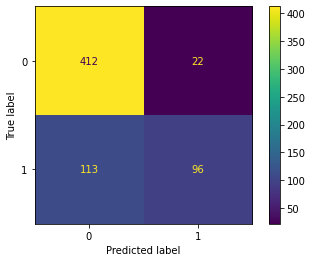

In [19]:
model_tree = DecisionTreeClassifier(random_state=12345, max_depth=4)
model_tree.fit(features_train, target_train)
cm_tree = confusion_matrix(target_test, model_tree.predict(features_test))
ConfusionMatrixDisplay(confusion_matrix, display_labels=None)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.show()

Теперь, модель случайного леса:

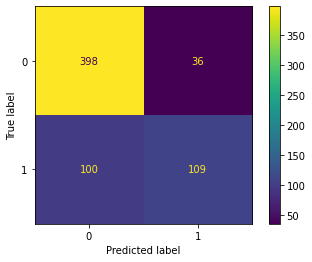

In [20]:
model_forest = RandomForestClassifier(random_state=12345, n_estimators=6)
model_forest.fit(features_train, target_train)
cm_forest = confusion_matrix(target_test, model_forest.predict(features_test))
ConfusionMatrixDisplay(confusion_matrix, display_labels=None)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest)
disp.plot()
plt.show()

Модель решающего дерева лучше предсказывает тариф смарт, но хуже тариф ультра, модель же случайного леса - наоборот. Для интереса посчитаем несчастную модель логистической регрессии:

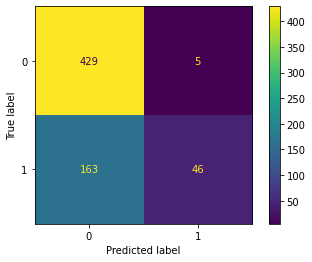

In [21]:
model_reg = LogisticRegression(solver = 'lbfgs')
model_reg.fit(features_train, target_train)
cm_reg = confusion_matrix(target_test, model_reg.predict(features_test))
ConfusionMatrixDisplay(confusion_matrix, display_labels=None)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reg)
disp.plot()
plt.show()

Эта модель совсем скошена в сторону тарифа смарт, сильно промахиваясь по тарифу ультра, очередной камень в ее огород.

Раз есть матрица ошибок, можно рассчитать и точность (presicion) и полноту (recall) для решающего дерева и случайного леса:

In [22]:
display("Полнота для решающего дерева" , recall_score(target_test, model_tree.predict(features_test)))
display("Точность для решающего дерева", precision_score(target_test, model_tree.predict(features_test)))
display("Полнота для случайного леса" , recall_score(target_test, model_forest.predict(features_test)))
display("Точность для случайного леса", precision_score(target_test, model_forest.predict(features_test)))

'Полнота для решающего дерева'

0.45933014354066987

'Точность для решающего дерева'

0.8135593220338984

'Полнота для случайного леса'

0.5215311004784688

'Точность для случайного леса'

0.7517241379310344

Мы видим то же соотношение, решающее дерево лучше определяет тариф смарт, но при этом она отправила в тариф ультра только 46% от того, что нужно было. Случайный лес определяет тариф смарт лучше, но чуть больше распознал тарифов ультра - 52% из всех. Оба параметра полноты, однако, низки - на тарифах ультра модели ошибаются в каждом втором случае.

По идее, это нужно попытаться исправить, обучив модели на сбалансированной выборке, порсто увеличив копированием количество тарифов ультра и снова все перемешав, но это выходит за пределы данной работы.

### Выводы

Анализ соотношения классов в моделях дерева и леса показывают, что обе они завышают количество тарифов смарт и занижают тарифы ультра. Модель логистической регрессии это делает еще больше. Это естественно ожидать из-за несимметричной выборки, ведущей к большей важности положительного предсказания тарифа смарт в ущерб тарифу ультра. Анализ матрицы ошибок, точности и полноты показывает то же самое - только половину тарифов ультра на тестовой выборке модели определяют верно.

Однако, ошибки приемлемы для точности моделей, а их исправление за счет балансировки выборки лежит за пределами данной работы.

<a id='outro'></a>
## Модель рекомендаций и общие выводы

Исходя из исследований выше, мы получили две примерно одинаковые по результатам модели - модель решающего дерева глубины 4 и модель случайного леса с 6-ю деревьями:

In [23]:
model = DecisionTreeClassifier(random_state=12345, max_depth=4)
model.fit(features_train, target_train)
predictions_test = model.predict(features_test)
result = accuracy_score(target_test, predictions_test)
display('Точность модели решающего дерева с глубиной 4 на тестовой выборке:')
display(accuracy_score(target_test, predictions_test))

'Точность модели решающего дерева с глубиной 4 на тестовой выборке:'

0.7900466562986003

In [24]:
model = RandomForestClassifier(random_state=12345, n_estimators=6)
model.fit(features_train, target_train)
predictions_test = model.predict(features_test)
result = accuracy_score(target_test, predictions_test)
display('Точность модели случайного леса с 6-ю деревьями на тестовой выборке:')
display(accuracy_score(target_test, predictions_test))

'Точность модели случайного леса с 6-ю деревьями на тестовой выборке:'

0.7884914463452566

Обе модели удовлетворяют требованиям заказчика (точность выше 75%). Выбрать из них мы считаем целесообразным модель решающего дерева, так как хотя она лишь немного выше по точности модели случайного леса, но она более производительна, что будет крайне важно для работы с огромными массивами данных федерального мобильного оператора.

Из ограничений это модели стоит выделить то, что она была обучена на несимметричной выборке, с большим перевесом в сторону тарифа смарт, поэтому склонна рекомендовать чаще тариф смарт нежели тариф ультра.

Это видно из матрицы ошибок или из полноты модели:

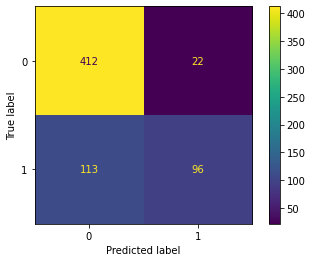

'Полнота для модели решающего дерева'

0.45933014354066987

In [25]:
model_tree = DecisionTreeClassifier(random_state=12345, max_depth=4)
model_tree.fit(features_train, target_train)
cm_tree = confusion_matrix(target_test, model_tree.predict(features_test))
ConfusionMatrixDisplay(confusion_matrix, display_labels=None)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.show()

display("Полнота для модели решающего дерева" , recall_score(target_test, model_tree.predict(features_test)))

Это потенциальная проблема для прибыльности модели, так как тариф ультра явно дороже тарифа смарт. Это можно исправить путем балансирования выборки, но согласно тех. заданию, это не входит в рамки данной работы.

В качестве альтернативы, если потеря производительности не критична, можно использовать модель случайного леса, чаще верно определяющую тариф ультра:

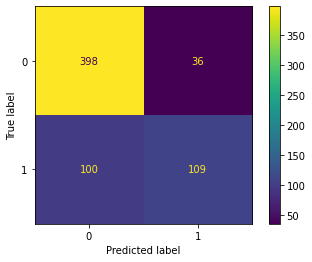

'Полнота для модели случайного леса'

0.5215311004784688

In [26]:
model_forest = RandomForestClassifier(random_state=12345, n_estimators=6)
model_forest.fit(features_train, target_train)
cm_forest = confusion_matrix(target_test, model_forest.predict(features_test))
ConfusionMatrixDisplay(confusion_matrix, display_labels=None)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest)
disp.plot()
plt.show()
display("Полнота для модели случайного леса" , recall_score(target_test, model_forest.predict(features_test)))

Увеличение составит около 6% - сумма, масштабирующаяся на больших объемах в огромную прибыль, упущенную в случае более производительной модели решающего дерева.

В итоге, заказчит может оценить, что более важно - упущенная прибыль или высокая произодительность.

Наша же рекомендация - доисследование за счет балансировки данных. Благодарим за внимание.